In [1]:
import pandas as pd
dataInFolder = './../data/'

In [2]:
kmdb = pd.read_csv(dataInFolder + 'kmdb_get_movie_list_20231103.csv')

column_dict = { 
	'movieCd':'영화코드', 'movieNm':'영화명국문', 'movieNmEn':'영화명(영문)', 
	'prdtYear':'제작연도', 'openDt':'개봉일', 'typeNm':'영화유형', 
	'prdtStatNm':'제작상태', 'nationAlt':'제작국가(전체)', 'genreAlt':'영화장르(전체)', 
	'repNationNm':'대표 제작 국가', 'repGenreNm':'대표 장르'
}

kmdb = kmdb.rename(columns=column_dict)
print(kmdb.columns)
kmdb.head()

Index(['영화코드', '영화명국문', '영화명(영문)', '제작연도', '개봉일', '영화유형', '제작상태', '제작국가(전체)',
       '영화장르(전체)', '대표 제작 국가', '대표 장르'],
      dtype='object')


,영화코드,영화명국문,영화명(영문),제작연도,개봉일,영화유형,제작상태,제작국가(전체),영화장르(전체),대표 제작 국가,대표 장르
0,20230966,사채소년,NaN,2023.0,NaN,장편,개봉예정,한국,액션,한국,액션
1,19820019,만추 리마스터링,Late Autumn,2010.0,20110217.0,장편,개봉,"한국,미국,홍콩",멜로/로맨스,한국,멜로/로맨스
2,20070458,냉정과 열정사이,Between Calm And Passion,2001.0,20031010.0,장편,개봉,일본,"멜로/로맨스,드라마",일본,멜로/로맨스
3,20226500,달짝지근해: 7510,HONEYSWEET,2022.0,20230815.0,장편,개봉,한국,코미디,한국,코미디
4,20235004,여귀교- 저주를 부르는 게임,The Bridge Curse : Ritua,2023.0,NaN,장편,개봉예정,대만,공포(호러),대만,공포(호러)


In [3]:
openYear = [str(item)[0:4] for item in kmdb['개봉일']]
kmdb['개봉년도'] = openYear
kmdb['개봉년월'] = [str(item)[0:6] for item in kmdb['개봉일']]
kmdb.head()

,영화코드,영화명국문,영화명(영문),제작연도,개봉일,영화유형,제작상태,제작국가(전체),영화장르(전체),대표 제작 국가,대표 장르,개봉년도,개봉년월
0,20230966,사채소년,NaN,2023.0,NaN,장편,개봉예정,한국,액션,한국,액션,nan,nan
1,19820019,만추 리마스터링,Late Autumn,2010.0,20110217.0,장편,개봉,"한국,미국,홍콩",멜로/로맨스,한국,멜로/로맨스,2011,201102
2,20070458,냉정과 열정사이,Between Calm And Passion,2001.0,20031010.0,장편,개봉,일본,"멜로/로맨스,드라마",일본,멜로/로맨스,2003,200310
3,20226500,달짝지근해: 7510,HONEYSWEET,2022.0,20230815.0,장편,개봉,한국,코미디,한국,코미디,2023,202308
4,20235004,여귀교- 저주를 부르는 게임,The Bridge Curse : Ritua,2023.0,NaN,장편,개봉예정,대만,공포(호러),대만,공포(호러),nan,nan


In [4]:
# 컬럼 재배치 작업
column01 = ['영화코드', '영화명국문', '영화명(영문)', '개봉년도', '개봉년월', '개봉일'] # 주요 컬럼
column02 = ['대표 제작 국가', '대표 장르', '영화유형', '제작상태', '영화장르(전체)', '제작국가(전체)', '제작연도'] # 일반 컬럼

myordering = column01 + column02

# 누락된 컬럼이 없는 지 확인
result = set(kmdb.columns) == set(myordering)
result

True

In [5]:
kmdb = kmdb[myordering]
kmdb.head()

,영화코드,영화명국문,영화명(영문),개봉년도,개봉년월,개봉일,대표 제작 국가,대표 장르,영화유형,제작상태,영화장르(전체),제작국가(전체),제작연도
0,20230966,사채소년,NaN,nan,nan,NaN,한국,액션,장편,개봉예정,액션,한국,2023.0
1,19820019,만추 리마스터링,Late Autumn,2011,201102,20110217.0,한국,멜로/로맨스,장편,개봉,멜로/로맨스,"한국,미국,홍콩",2010.0
2,20070458,냉정과 열정사이,Between Calm And Passion,2003,200310,20031010.0,일본,멜로/로맨스,장편,개봉,"멜로/로맨스,드라마",일본,2001.0
3,20226500,달짝지근해: 7510,HONEYSWEET,2023,202308,20230815.0,한국,코미디,장편,개봉,코미디,한국,2022.0
4,20235004,여귀교- 저주를 부르는 게임,The Bridge Curse : Ritua,nan,nan,NaN,대만,공포(호러),장편,개봉예정,공포(호러),대만,2023.0


In [6]:
kmdb['대표 장르'].unique()

array(['액션', '멜로/로맨스', '코미디', '공포(호러)', '드라마', nan, '성인물(에로)', 'SF',
       '애니메이션', '기타', '판타지', '범죄', '공연', '스릴러', '다큐멘터리', '미스터리', '뮤지컬',
       '전쟁', '어드벤처', '가족', '서부극(웨스턴)', '사극'], dtype=object)

In [7]:
genre_filter = ['드라마', '코미디', '판타지', '액션']
genre_result = kmdb[kmdb['대표 장르'].isin(genre_filter)]
genre_result['대표 장르'].unique()

array(['액션', '코미디', '드라마', '판타지'], dtype=object)

In [8]:
chartData = genre_result['대표 장르'].value_counts()
chartData.to_frame()

,count
대표 장르,
드라마,22003
액션,6176
코미디,5277
판타지,588


In [9]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

<Axes: ylabel='count'>

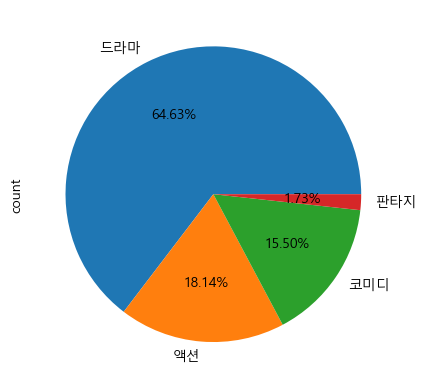

In [10]:
chartData.plot(kind='pie', autopct='%1.2f%%')

In [11]:
genre_filter = ['드라마', '애니메이션', '범죄', '코미디', '스릴러']
genre_result = kmdb[kmdb['대표 장르'].isin(genre_filter)]
genre_result['대표 장르'].unique()

array(['코미디', '드라마', '애니메이션', '범죄', '스릴러'], dtype=object)

In [12]:
genreGrouping = genre_result.groupby('대표 장르')['대표 장르']
genreChart = genreGrouping.count().sort_values()
genreChart.to_frame()

,대표 장르
대표 장르,
범죄,1523
스릴러,1870
코미디,5277
애니메이션,8638
드라마,22003


<Axes: xlabel='대표 장르'>

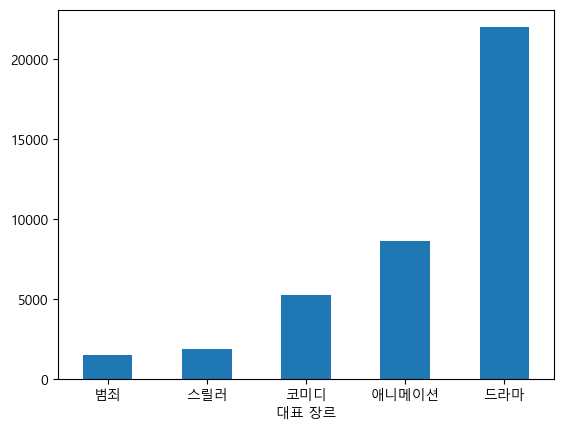

In [13]:
genreChart.plot(kind='bar', rot=0)

In [14]:
# 대표 제작 국가 : 미국 일본 중국 한국에 대하여 데이터를 추출하고 수평 막대 그래프 그리기
# 출력 순서는 국가 명 가나다 순으로 보여 주세요

In [15]:
nationName = pd.Series(kmdb['대표 제작 국가'].unique())
# type(nationAlt)
nationName.sort_values().to_frame().head()

,0
56,그리스
13,기타
59,나이지리아
60,남아프리카공화국
26,네덜란드


In [16]:
filter_nation = ['미국', '일본', '중국', '한국']
nation_name_data = kmdb[kmdb['대표 제작 국가'].isin(filter_nation)]
nation_name_data['대표 제작 국가'].unique()

array(['한국', '일본', '미국', '중국'], dtype=object)

In [17]:
nation_name_grouping = nation_name_data.groupby('대표 제작 국가')['대표 제작 국가']
nation_name_chart = nation_name_grouping.count().sort_index()
nation_name_chart.to_frame()

,대표 제작 국가
대표 제작 국가,
미국,15761
일본,11963
중국,1951
한국,33049


<Axes: ylabel='대표 제작 국가'>

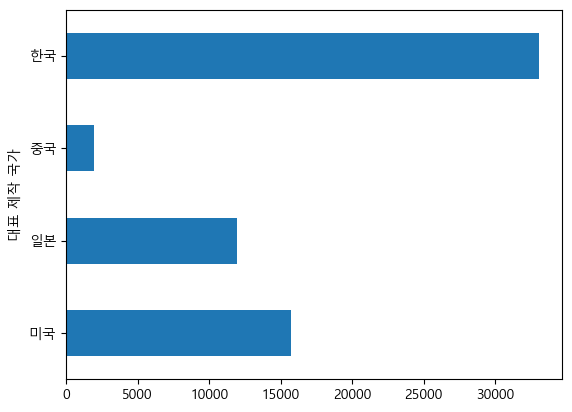

In [18]:
nation_name_chart.plot(kind='barh', rot = 0)

In [19]:
nation = ['한국', '미국', '일본']
result = kmdb[kmdb['대표 제작 국가'].isin(nation)]

genre = ['범죄', '코미디', '스릴러', '뮤지컬']
result = result[result['대표 장르'].isin(genre)]

print('대표 제작 국가 이름 : ', end='')
print(result['대표 제작 국가'].unique())
print('대표 장르 이름 : ', end='')
print(result['대표 장르'].unique())

대표 제작 국가 이름 : ['한국' '미국' '일본']
대표 장르 이름 : ['코미디' '범죄' '스릴러' '뮤지컬']


In [20]:
resultGroup = result.groupby(['대표 제작 국가', '대표 장르'])['대표 제작 국가']
barChartData = resultGroup.count().to_frame()
barChartData = barChartData.rename(columns={'대표 제작 국가':'cnt'}) # 컬럼 이름 변경
barChartData.reset_index()

,대표 제작 국가,대표 장르,cnt
0,미국,뮤지컬,88
1,미국,범죄,670
2,미국,스릴러,787
3,미국,코미디,2054
4,일본,범죄,64
5,일본,스릴러,79
6,일본,코미디,241
7,한국,뮤지컬,73
8,한국,범죄,205
9,한국,스릴러,422


In [21]:
barChart = pd.pivot_table(barChartData, index='대표 제작 국가', columns='대표 장르', values='cnt', aggfunc='mean')
barChart

대표 장르,뮤지컬,범죄,스릴러,코미디
대표 제작 국가,,,,
미국,88.0,670.0,787.0,2054.0
일본,NaN,64.0,79.0,241.0
한국,73.0,205.0,422.0,969.0


Text(0.5, 1.0, '국가별 장르별 다변량 수직 막대 그래프')

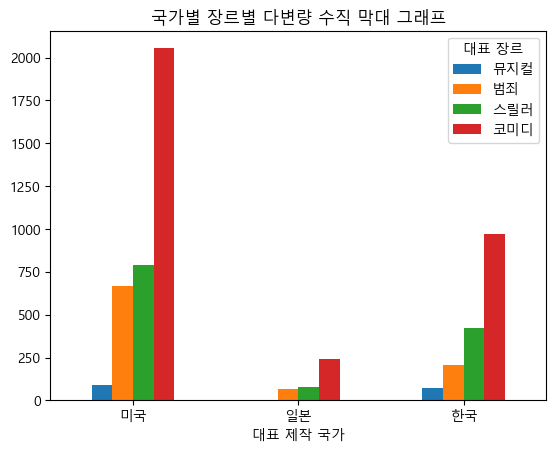

In [22]:
barChart.plot(kind='bar', rot=0)
plt.title('국가별 장르별 다변량 수직 막대 그래프')

Text(0.5, 1.0, '장르별 국가별 다변량 수직 막대 그래프')

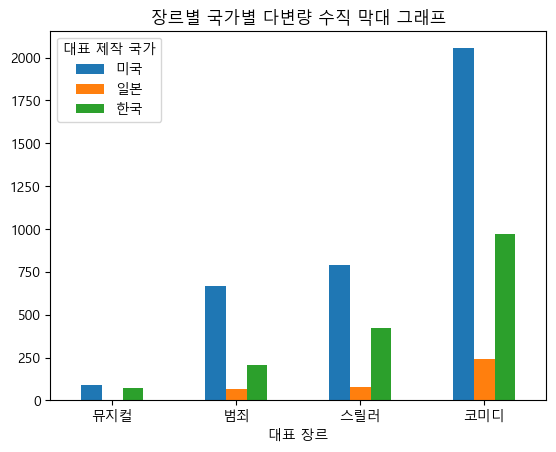

In [23]:
barChart.T.plot(kind='bar', rot=0)
plt.title('장르별 국가별 다변량 수직 막대 그래프')

In [ ]:
# sorted : 정렬을 수행하는 내장 함수
sorted(kmdb['개봉년월'].unique())

In [ ]:
# 2022년과 2023년도 데이터만 필터링
year2022 = ['2022' + str(idx).zfill(2) for idx in range(1, 13)]
year2023 = ['2023' + str(idx).zfill(2) for idx in range(1, 13)]

myyear = year2022 + year2023
recentKmdb = kmdb[kmdb['개봉년월'].isin(myyear)]
recentKmdb

In [ ]:
openMonth = recentKmdb.groupby('개봉년월')['개봉년월']
openChart = openMonth.count()
openChart.to_frame()

([<matplotlib.axis.XTick at 0x1ef8f8e0dd0>,
 [Text(0, 0, '202201'),
  Text(1, 0, '202202'),
  Text(2, 0, '202203'),
  Text(3, 0, '202204'),
  Text(4, 0, '202205'),
  Text(5, 0, '202206'),
  Text(6, 0, '202207'),
  Text(7, 0, '202208'),
  Text(8, 0, '202209'),
  Text(9, 0, '202210'),
  Text(10, 0, '202211'),
  Text(11, 0, '202212'),
  Text(12, 0, '202301'),
  Text(13, 0, '202302'),
  Text(14, 0, '202303'),
  Text(15, 0, '202304'),
  Text(16, 0, '202305'),
  Text(17, 0, '202306'),
  Text(18, 0, '202307'),
  Text(19, 0, '202308'),
  Text(20, 0, '202309'),
  Text(21, 0, '202310'),
  Text(22, 0, '202311')])

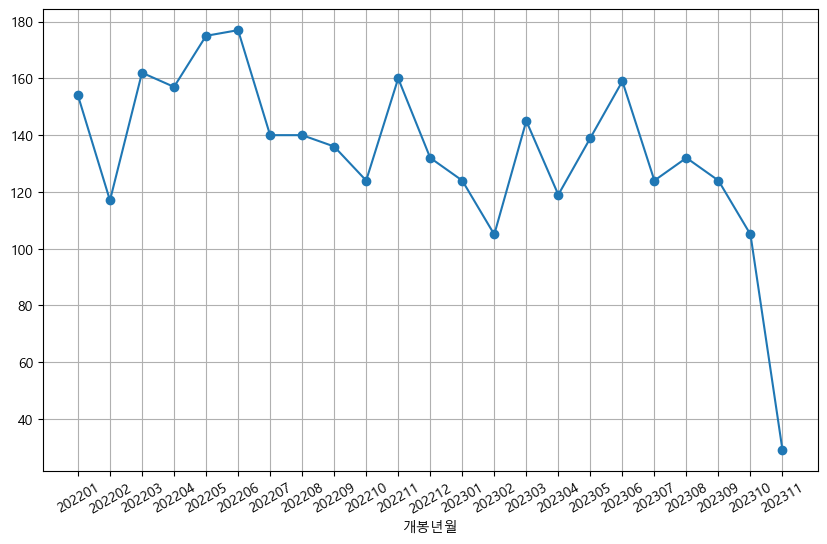

In [27]:
plt.title('개봉 년월에 따른 빈도수 그래프')
openChart.plot(kind='line', grid=True, figsize=(10, 6), marker='o', rot=30)
plt.xticks(range(len(openChart.index)), openChart.index)  # plt.xticks(숫자, 표시할글자)

In [28]:
# 대륙별 데이터 파악
# '아시아', '북중미', '유럽'에 대하여 파이 그래프 그리기

In [29]:
nationList = recentKmdb['대표 제작 국가'].unique()
nationList

array(['한국', '프랑스', '미국', '일본', '호주', '중국', '홍콩', '기타', '스페인', '영국',
       '우크라이나', '멕시코', '독일', '대만', '이탈리아', '폴란드', '칠레', '벨기에', '노르웨이',
       '네덜란드', '러시아', '헝가리', '캐나다', '체코', '브라질', '핀란드', '아일랜드', '인도네시아',
       '아르헨티나', '인도', '이스라엘', '덴마크', '오스트리아 ', '스위스', '아이슬란드', '이집트',
       '베트남', '에스토니아', '필리핀', '페루', '카자흐스탄', '루마니아', '우루과이', '뉴질랜드',
       '남아프리카공화국'], dtype=object)

In [ ]:
region_txt = open(dataInFolder + 'region.txt', mode='rt', encoding='UTF-8')

region_dict = dict()

region_list = region_txt.readlines()
for oneline in region_list:
    nation = oneline.replace('\n', '').split(':')
    region_dict[nation[0]] = nation[1]
# end for

region_dict

In [ ]:
# '대표 제작 국가'를 이용하여 사전에서 '대륙' 이름을 찾아서 파생 컬럼 '대륙'에 추가합니다.
# region_dict.get(nation, nation) --> region_dict.get(입력값, 기본값)
recentKmdb.loc[:, '대륙'] = recentKmdb.loc[:, '대표 제작 국가'].apply(lambda nation : region_dict.get(nation, nation))
recentKmdb.loc[:, ['대표 제작 국가', '대륙']].head()

In [ ]:
nTop = 4
continent = recentKmdb['대륙'].value_counts().to_frame()
continent = continent.nlargest(nTop, 'count') # 상위 nTop 개 만큼 필터링
continent

array([<Axes: ylabel='count'>], dtype=object)

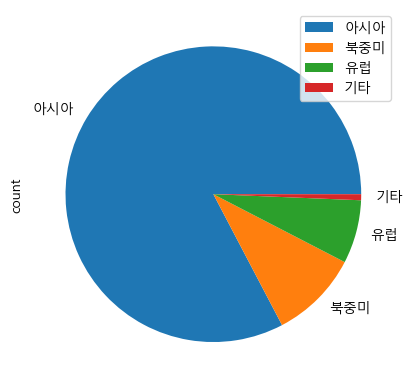

In [41]:
continent.plot(kind='pie', subplots=True)

In [42]:
detail = pd.read_csv(dataInFolder + 'kmdb_get_movie_detail_list(한국_액션,코미디).csv')
print('행수 : ' + str(len(detail)))
detail.columns

행수 : 387


Index(['movieCode', 'key', 'value'], dtype='object')

In [43]:
detail.head()

,movieCode,key,value
0,20210544,movieCd,20210544
1,20210544,movieNm,웅남이
2,20210544,movieNmEn,woongnami
3,20210544,movieNmOg,NaN
4,20210544,showTm,97


In [ ]:
# 다음 문장은 오류가 발생합니다.
df = detail.pivot(index='movieCode', columns='key', values='value')
df

In [ ]:
pivot_frame = detail.pivot_table(index='movieCode', columns='key', values='value', aggfunc='count')
pivot_frame

In [46]:
many_rows = pivot_frame[pivot_frame['movieCd'] >= 2]
many_rows

key,movieCd,movieNm,movieNmEn,movieNmOg,openDt,prdtStatNm,prdtYear,showTm,typeNm
movieCode,,,,,,,,,
20210544,2,2,2,0,2,2,2,2,2
20211317,2,2,2,2,2,2,2,2,2
20214823,2,2,2,0,2,2,2,2,2


In [47]:
# duplicated 함수는 모든 행이 완전 일치하는 지를 체크해주는 함수입니다.
# 완전 일치하는 행의 1번째 행만 False이고, 나머지 행들은 모두 True가 됩니다.
# ~ 기호는 python의 not, 자바의 ! 기호가 동일한 역할을 합니다.
duplicates = ~detail.duplicated()
duplicates

# 중복된 데이터는 추려서 1개만 보여주는 역할을 합니다.
detail = detail[duplicates] 
print('행수 : ' + str(len(detail)))

detail_wide = detail.pivot(index='movieCode', columns='key', values='value')
detail_wide.head()

행수 : 360


key,movieCd,movieNm,movieNmEn,movieNmOg,openDt,prdtStatNm,prdtYear,showTm,typeNm
movieCode,,,,,,,,,
20180382,20180382,일진 2,NaN,NaN,20220625,개봉,2018,81,장편
20191223,20191223,대가리2-학교무림,NaN,NaN,20220624,개봉,2019,83,장편
20194425,20194425,대가리,NaN,NaN,20220624,개봉,2019,83,장편
20196306,20196306,일진 3,NaN,NaN,20220625,개봉,2018,80,장편
20196906,20196906,스텔라,Stellar,NaN,20220406,개봉,2021,98,장편


In [48]:
rename_dict = {
    'movieCd':'영화코드', 'movieNm':'영화명국문', 'movieNmEn':'영화명(영문)', \
    'movieNmOg':'영화명(원문)', 'prdtYear':'제작연도', 'showTm':'상영시간', \
    'openDt':'개봉연도', 'prdtStatNm':'제작상태', 'typeNm':'영화유형', \
    'nations':'제작국가', 'nationNm':'제작국가', 'genreNm':'장르', \
    'directors':'감독', 'peopleNm':'감독', 'peopleNmEn':'감독명(영문)', \
    'actors':'배우', 'peopleNm':'배우', 'peopleNmEn':'배우명(영문)', \
    'cast':'배역', 'castEn':'배역명(영문)', 'showTypes':'상영형태 구분', \
    'showTypeGroupNm':'상영형태 구분', 'showTypeNm':'상영형태', 'audits':'심의정보', \
    'auditNo':'심의번호', 'watchGradeNm':'관람등급 명칭', 'companys':'참여 영화사', \
    'companyCd':'참여 영화사 코드', 'companyNm':'참여 영화사', 'companyNmEn':'참여 영화사명(영문)', 
    'companyPartNm':'참여 영화사 분야', 'staffs':'스텝', 'peopleNm':'스텝', \
    'peopleNmEn':'스텝명(영문)', 'staffRoleNm':'스텝역할', 'nations':'국가', 'genres':'장르'}

detail_wide = detail_wide.rename(columns=rename_dict) 
detail_wide.head()

key,영화코드,영화명국문,영화명(영문),영화명(원문),개봉연도,제작상태,제작연도,상영시간,영화유형
movieCode,,,,,,,,,
20180382,20180382,일진 2,NaN,NaN,20220625,개봉,2018,81,장편
20191223,20191223,대가리2-학교무림,NaN,NaN,20220624,개봉,2019,83,장편
20194425,20194425,대가리,NaN,NaN,20220624,개봉,2019,83,장편
20196306,20196306,일진 3,NaN,NaN,20220625,개봉,2018,80,장편
20196906,20196906,스텔라,Stellar,NaN,20220406,개봉,2021,98,장편


In [49]:
detail_wide.columns

Index(['영화코드', '영화명국문', '영화명(영문)', '영화명(원문)', '개봉연도', '제작상태', '제작연도', '상영시간',
       '영화유형'],
      dtype='object', name='key')

In [50]:
actors = pd.read_csv(dataInFolder + 'kmdb_get_actor_list(한국_액션,코미디).csv')
rename_dict ={'peopleNm':'배우', 'peopleNmEn':'배우(영문)', 'cast':'캐스팅', 
              'castEn':'캐스팅(영문)', 'movieCode':'영화코드'}
actors = actors.rename(columns=rename_dict)
actors.head()

,배우,배우(영문),캐스팅,캐스팅(영문),영화코드
0,설경구,SUL Kyung-gu,NaN,NaN,20214823
1,이하늬,LEE Ha-nee,NaN,NaN,20214823
2,박소담,PARK So-dam,NaN,NaN,20214823
3,박해수,PARK Haesoo,NaN,NaN,20214823
4,서현우,SEO Hyun-woo,NaN,NaN,20214823


In [51]:
actors.columns

Index(['배우', '배우(영문)', '캐스팅', '캐스팅(영문)', '영화코드'], dtype='object')